# 04 - Noise and decoherence

Real devices are noisy. Gates have finite fidelity, qubits decohere over time, measurement has readout errors. This notebook is about understanding the physics of this and how to model it in simulation.

The formalism: open quantum systems. The qubit is coupled to an environment, and tracing out the environment gives a density matrix evolving under a CPTP (completely positive, trace preserving) map. Any such map has a Kraus decomposition:

$$\mathcal{E}(\rho) = \sum_k K_k \rho K_k^\dagger, \quad \sum_k K_k^\dagger K_k = I$$

For unitary evolution there is one Kraus operator K_0 = U. Noise adds more. The physics of which Kraus operators appear depends on the system-environment coupling.

Im coming to this wanting to understand what qiskit-aer actually simulates when you add a noise model, and what the parameters mean physically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel, depolarizing_error, amplitude_damping_error,
    phase_damping_error, thermal_relaxation_error
)
from qiskit.quantum_info import DensityMatrix, Statevector, state_fidelity, entropy
from qiskit.visualization import plot_histogram

import warnings
warnings.filterwarnings('ignore')

sim = AerSimulator()

## Density matrices and mixed states

A pure state rho = |psi><psi| has Tr(rho^2) = 1. A mixed state - a statistical mixture or the result of tracing out an environment - has Tr(rho^2) < 1. The maximally mixed state is I/2, which carries no quantum information about the original state.

The purity Tr(rho^2) is a simple measure of how much noise has degraded the state.

In [2]:
I = np.eye(2, dtype=complex)
X = np.array([[0,1],[1,0]], dtype=complex)
Y = np.array([[0,-1j],[1j,0]], dtype=complex)
Z = np.array([[1,0],[0,-1]], dtype=complex)

def apply_channel(rho, kraus):
    return sum(K @ rho @ K.conj().T for K in kraus)

rho_plus = np.array([[1,1],[1,1]]) / 2  # pure state |+>
rho_mixed = np.eye(2) / 2              # maximally mixed

print('purity |+>:     ', np.trace(rho_plus @ rho_plus).real)
print('purity max mixed:', np.trace(rho_mixed @ rho_mixed).real)

purity |+>:      1.0
purity max mixed: 0.5


## The main noise channels

### Depolarizing channel

With probability p, a random Pauli (X, Y, or Z with equal probability p/4 each, identity with probability 1-3p/4) is applied. This is the most common approximation for gate errors.

$$\mathcal{E}_{dep}(\rho) = (1-p)\rho + \frac{p}{4}(X\rho X + Y\rho Y + Z\rho Z + \rho)$$

At p=1, this maps everything to I/2 - the maximally mixed state.

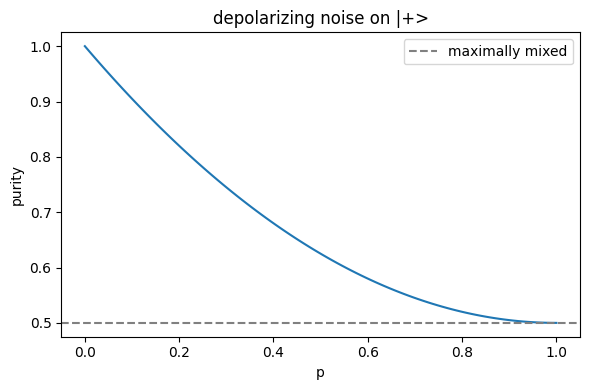

In [3]:
def depolarizing_kraus(p):
    return [
        np.sqrt(1-3*p/4)*I,
        np.sqrt(p/4)*X,
        np.sqrt(p/4)*Y,
        np.sqrt(p/4)*Z,
    ]

ps = np.linspace(0, 1, 100)
purities = [np.trace(apply_channel(rho_plus, depolarizing_kraus(p)) @ 
                     apply_channel(rho_plus, depolarizing_kraus(p))).real for p in ps]

plt.figure(figsize=(6,4))
plt.plot(ps, purities)
plt.axhline(0.5, color='gray', linestyle='--', label='maximally mixed')
plt.xlabel('p'); plt.ylabel('purity')
plt.title('depolarizing noise on |+>')
plt.legend(); plt.tight_layout(); plt.show()

### Amplitude damping (T1 decay)

Models energy relaxation: the qubit decays from |1> to |0> by emitting to the environment, like a two-level atom spontaneously emitting a photon. The Kraus operators are:

$$K_0 = \begin{pmatrix}1 & 0 \\ 0 & \sqrt{1-\gamma}\end{pmatrix}, \quad K_1 = \begin{pmatrix}0 & \sqrt{\gamma} \\ 0 & 0\end{pmatrix}$$

The parameter gamma = 1 - e^{-t/T1} where T1 is the energy relaxation time.

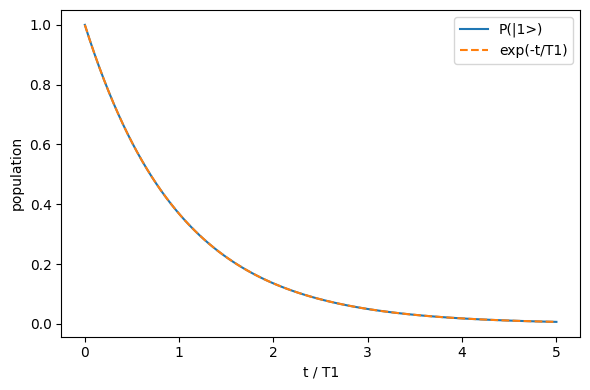

In [4]:
def amp_damp_kraus(gamma):
    return [
        np.array([[1,0],[0,np.sqrt(1-gamma)]], dtype=complex),
        np.array([[0,np.sqrt(gamma)],[0,0]], dtype=complex)
    ]

rho1 = np.array([[0,0],[0,1]], dtype=complex)  # |1>
T1, times = 1.0, np.linspace(0, 5, 100)

p1 = [apply_channel(rho1, amp_damp_kraus(1-np.exp(-t/T1)))[1,1].real for t in times]

plt.figure(figsize=(6,4))
plt.plot(times, p1, label='P(|1>)')
plt.plot(times, np.exp(-times/T1), '--', label='exp(-t/T1)')
plt.xlabel('t / T1'); plt.ylabel('population')
plt.legend(); plt.tight_layout(); plt.show()

### Phase damping (T2 dephasing)

Loss of phase coherence without energy exchange - the environment learns which state the qubit is in without absorbing energy. Destroys the off-diagonal elements of rho (coherences) while leaving populations unchanged.

$$K_0 = \begin{pmatrix}1 & 0 \\ 0 & \sqrt{1-\lambda}\end{pmatrix}, \quad K_1 = \begin{pmatrix}0 & 0 \\ 0 & \sqrt{\lambda}\end{pmatrix}$$

The relation between T1 and T2 is 1/T2 = 1/(2T1) + 1/T_phi where T_phi is the pure dephasing time. So T2 <= 2*T1 always.

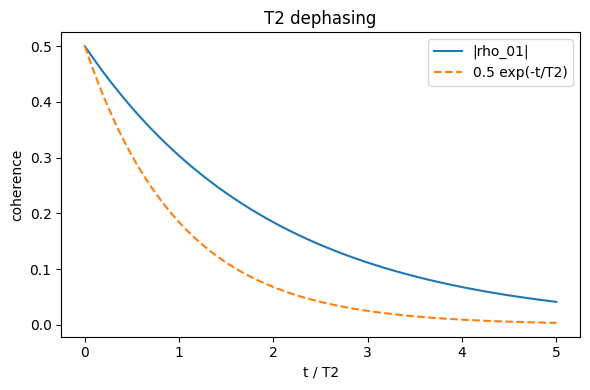

In [5]:
def phase_damp_kraus(lam):
    return [
        np.array([[1,0],[0,np.sqrt(1-lam)]], dtype=complex),
        np.array([[0,0],[0,np.sqrt(lam)]], dtype=complex)
    ]

T2 = 1.0
coherences = [abs(apply_channel(rho_plus, phase_damp_kraus(1-np.exp(-t/T2)))[0,1]) for t in times]

plt.figure(figsize=(6,4))
plt.plot(times, coherences, label='|rho_01|')
plt.plot(times, 0.5*np.exp(-times/T2), '--', label='0.5 exp(-t/T2)')
plt.xlabel('t / T2'); plt.ylabel('coherence')
plt.title('T2 dephasing')
plt.legend(); plt.tight_layout(); plt.show()

## Noise models in qiskit-aer

Aer lets you attach noise channels to specific gates via a NoiseModel object. The noise is applied after each gate of the specified type. You can mix different error types - depolarizing on gates, thermal relaxation for idle time, readout errors on measurement.

Thermal relaxation is the physically motivated one: it combines T1 decay and T2 dephasing for a gate of a given duration.

In [11]:
def build_noise_model(p_1q, p_2q):
    nm = NoiseModel()
    
    # 1. Parámetros de relajación térmica estables
    # T1 debe ser >= T2. Lo habitual es T1 > T2.
    t1, t2, gate_time = 50, 40, 0.1 
    
    # Error térmico de 1 qubit
    error_thermal_1q = thermal_relaxation_error(t1, t2, gate_time)
    # Error térmico de 2 qubits (producto tensorial)
    error_thermal_2q = error_thermal_1q.tensor(error_thermal_1q)
    
    # 2. Errores de despolarización
    err_1q = depolarizing_error(p_1q, 1)
    err_2q = depolarizing_error(p_2q, 2)

    # 3. Combinar y añadir (sin repetir instrucciones innecesariamente)
    # Combinamos el error térmico con el de despolarización para que sea un solo bloque
    full_err_1q = error_thermal_1q.compose(err_1q)
    full_err_2q = error_thermal_2q.compose(err_2q)

    # Añadimos a las puertas correspondientes
    nm.add_all_qubit_quantum_error(full_err_1q, ['h', 'x', 'ry', 'rz'])
    nm.add_all_qubit_quantum_error(full_err_2q, ['cx'])

    return nm

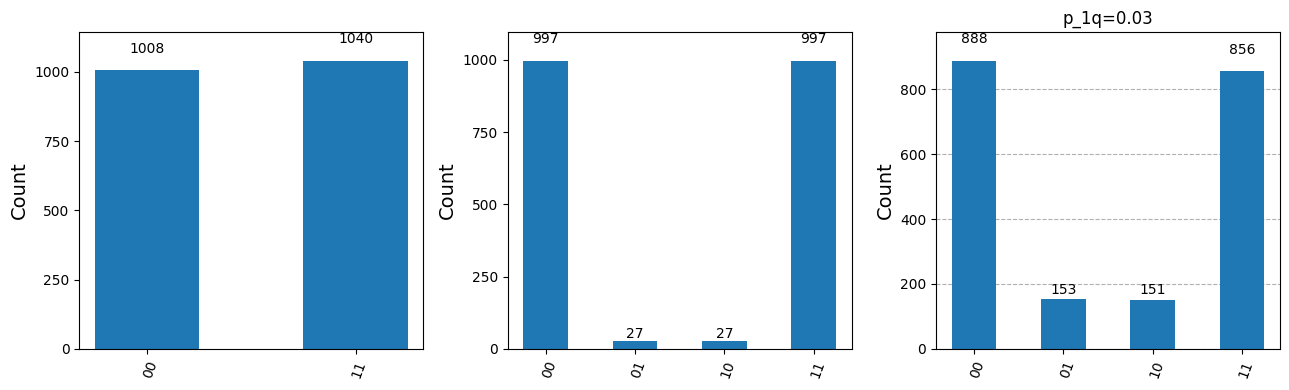

In [12]:
# Bell state at different noise levels
qc_bell = QuantumCircuit(2)
qc_bell.h(0); qc_bell.cx(0,1); qc_bell.measure_all()

fig, axes = plt.subplots(1,3, figsize=(13,4))
for ax, p in zip(axes, [0.0, 0.005, 0.03]):
    if p == 0:
        counts = sim.run(qc_bell, shots=2048).result().get_counts()
        title = 'ideal'
    else:
        ns = AerSimulator(noise_model=build_noise_model(p_1q=p, p_2q=p*10))
        counts = ns.run(qc_bell, shots=2048).result().get_counts()
        title = f'p_1q={p}'
    plot_histogram(counts, ax=ax, title=title)
plt.tight_layout(); plt.show()

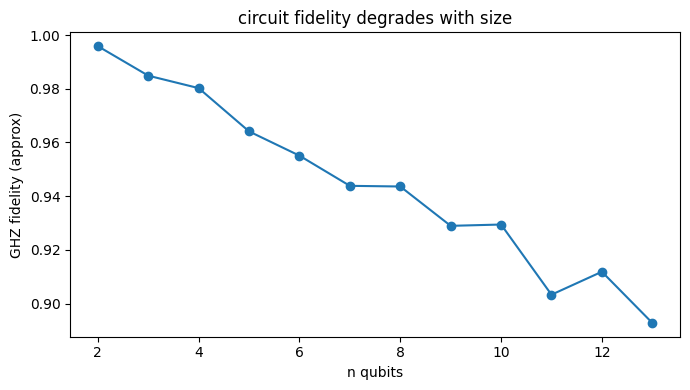

In [13]:
# fidelity as a function of circuit depth
# use GHZ as a benchmark - requires n-1 CNOTs so depth grows linearly with n

def ghz(n):
    qc = QuantumCircuit(n)
    qc.h(0)
    for i in range(n-1): qc.cx(i, i+1)
    return qc

nm = build_noise_model(p_1q=0.003, p_2q=0.01)
noisy_sim = AerSimulator(noise_model=nm)

ns_range = range(2, 14)
fidelities = []

for n in ns_range:
    qc = ghz(n); qc.measure_all()
    counts = noisy_sim.run(qc, shots=4096).result().get_counts()
    total = sum(counts.values())
    p_correct = (counts.get('0'*n, 0) + counts.get('1'*n, 0)) / total
    fidelities.append(p_correct)

plt.figure(figsize=(7,4))
plt.plot(list(ns_range), fidelities, 'o-')
plt.xlabel('n qubits'); plt.ylabel('GHZ fidelity (approx)')
plt.title('circuit fidelity degrades with size')
plt.tight_layout(); plt.show()

## Measurement error mitigation

The simplest mitigation: calibrate the readout confusion matrix M where M_ij = P(measure i | prepared j), then invert to correct raw counts. This doesnt touch gate errors at all, just readout.

For n qubits the full confusion matrix is 2^n x 2^n, which is expensive to calibrate. In practice people often assume uncorrelated readout errors and use a product of single-qubit matrices.

In [14]:
from qiskit_aer.noise import ReadoutError

p10, p01 = 0.04, 0.02  # P(1|0) and P(0|1)
ro_nm = NoiseModel()
ro_nm.add_all_qubit_readout_error(ReadoutError([[1-p10, p10],[p01, 1-p01]]))
ro_sim = AerSimulator(noise_model=ro_nm)

shots = 8192

# calibrate: prepare |0> and |1>, measure both
def prep_and_measure(gate=None):
    qc = QuantumCircuit(1,1)
    if gate: getattr(qc, gate)(0)
    qc.measure(0,0)
    return ro_sim.run(qc, shots=shots).result().get_counts()

c0 = prep_and_measure()
c1 = prep_and_measure('x')

M = np.array([
    [c0.get('0',0)/shots, c1.get('0',0)/shots],
    [c0.get('1',0)/shots, c1.get('1',0)/shots]
])
print('calibration matrix M:')
print(np.round(M, 4))

calibration matrix M:
[[0.9584 0.0211]
 [0.0416 0.9789]]


In [15]:
# measure |+> and correct
qc_plus = QuantumCircuit(1,1)
qc_plus.h(0); qc_plus.measure(0,0)
c_noisy = ro_sim.run(qc_plus, shots=shots).result().get_counts()

p_raw = np.array([c_noisy.get('0',0), c_noisy.get('1',0)]) / shots
p_corrected = np.linalg.solve(M, p_raw)
p_corrected = np.clip(p_corrected, 0, 1)
p_corrected /= p_corrected.sum()

print(f'raw:       P(0)={p_raw[0]:.4f}, P(1)={p_raw[1]:.4f}')
print(f'corrected: P(0)={p_corrected[0]:.4f}, P(1)={p_corrected[1]:.4f}')
print(f'ideal:     P(0)=0.5000, P(1)=0.5000')

raw:       P(0)=0.4890, P(1)=0.5110
corrected: P(0)=0.4992, P(1)=0.5008
ideal:     P(0)=0.5000, P(1)=0.5000


Readout mitigation is easy to apply and always worth doing. Gate errors require error correction, which is a completely different thing - next notebook.